# 03 — Análisis del Dataset Artificial

**Objetivo:** Verificar que el dataset artificial generado en el notebook 02 tiene
distribuciones coherentes con el mercado real y que las anomalías inyectadas son
visualmente distinguibles de los registros normales.

**Prerequisito:** `datasets/properties_synthetic_v1.parquet` generado por el notebook 02.

In [1]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', '{:,.2f}'.format)

DATA_PATH = pathlib.Path('../datasets/properties_synthetic_v1.parquet')
assert DATA_PATH.exists(), f'No se encontró {DATA_PATH}. Ejecuta primero el notebook 02.'

df = pd.read_parquet(DATA_PATH)
normal   = df[~df['is_anomaly']]
anomalos = df[df['is_anomaly']]

print(f'Total de registros : {len(df):,}')
print(f'  Normales         : {len(normal):,}  ({len(normal)/len(df):.1%})')
print(f'  Anómalos         : {len(anomalos):,}  ({len(anomalos)/len(df):.1%})')
print(f'\nTipos de anomalía:')
print(anomalos['anomaly_type'].value_counts().to_string())

Total de registros : 6,240
  Normales         : 6,000  (96.2%)
  Anómalos         : 240  (3.8%)

Tipos de anomalía:
anomaly_type
ano_construccion_inv    60
area_imposible          60
ppm2_incoherente        60
precio_absurdo          60


## 1. Resumen estadístico

In [2]:
FEATURE_COLS = [
    'areaM2', 'listedPrice', 'pricePerM2', 'bedrooms', 'bathrooms',
    'parkingSpaces', 'antiguedad', 'condominium', 'n_amenities', 'total_images',
]

print('=== NORMALES ===')
display(normal[FEATURE_COLS].describe().T.round(2))

print('\n=== ANÓMALOS ===')
display(anomalos[FEATURE_COLS].describe().T.round(2))

=== NORMALES ===


,count,mean,std,min,25%,50%,75%,max
areaM2,"6,000.00",284.90,179.85,10.10,135.40,250.40,432.42,662.90
listedPrice,"6,000.00","3,648,307.02","2,982,893.55","1,166.91","1,258,967.84","2,864,698.22","5,388,480.25","14,867,190.93"
pricePerM2,"6,000.00","13,934.92","8,976.78",105.78,"7,579.64","12,913.40","18,429.15","52,799.96"
bedrooms,"6,000.00",2.71,1.27,0.00,2.00,3.00,4.00,8.00
bathrooms,"6,000.00",1.50,0.69,0.00,1.00,1.50,2.00,4.40
parkingSpaces,"6,000.00",1.02,0.73,0.00,1.00,1.00,1.00,4.00
antiguedad,"6,000.00",36.58,14.83,2.00,27.00,37.00,46.00,93.00
condominium,"6,000.00",0.30,0.46,0.00,0.00,0.00,1.00,1.00
n_amenities,"6,000.00",6.99,4.33,0.00,3.00,7.00,11.00,14.00
total_images,"6,000.00",12.65,6.84,1.00,7.00,13.00,19.00,24.00



=== ANÓMALOS ===


,count,mean,std,min,25%,50%,75%,max
areaM2,240.00,"3,260.11","8,858.67",1.37,67.00,267.80,500.20,"46,978.01"
listedPrice,240.00,"14,234,537.62","28,530,387.00","62,868.47","1,647,420.88","4,726,403.23","9,208,081.22","225,010,800.74"
pricePerM2,240.00,"247,123.66","591,881.25",9.96,"2,361.71","22,102.46","249,644.81","4,186,745.77"
bedrooms,240.00,2.70,1.30,0.00,2.00,3.00,3.25,7.00
bathrooms,240.00,1.52,0.65,0.00,1.10,1.60,1.92,3.20
parkingSpaces,240.00,1.02,0.72,0.00,1.00,1.00,1.00,3.00
antiguedad,240.00,45.29,59.08,-71.00,21.75,36.50,53.00,222.00
condominium,240.00,0.27,0.45,0.00,0.00,0.00,1.00,1.00
n_amenities,240.00,7.10,4.37,0.00,3.00,7.00,11.00,14.00
total_images,240.00,13.08,6.75,1.00,7.00,14.00,19.00,24.00


## 2. Distribuciones: normales vs anómalos

Para cada feature numérica clave, mostramos el histograma de registros normales (azul)
superpuesto con los anómalos (rojo). Las anomalías deberían caer en las colas.

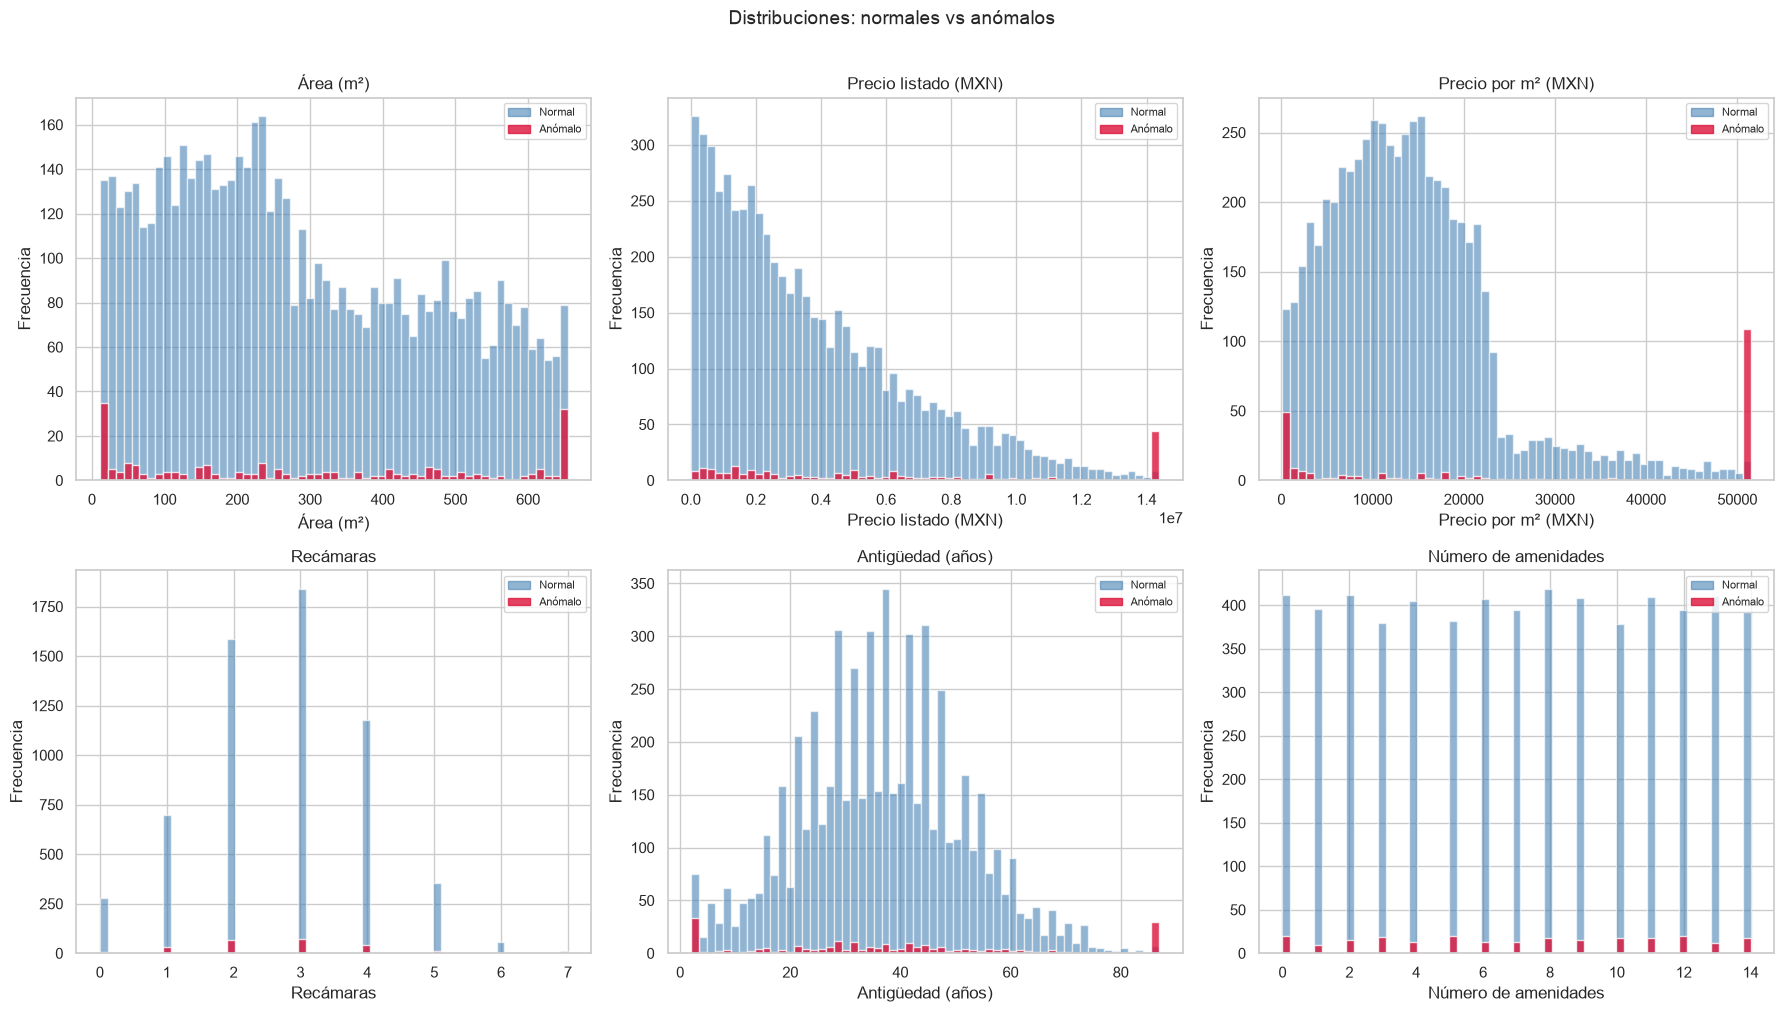

In [3]:
PLOT_FEATURES = [
    ('areaM2',       'Área (m²)'),
    ('listedPrice',  'Precio listado (MXN)'),
    ('pricePerM2',   'Precio por m² (MXN)'),
    ('bedrooms',     'Recámaras'),
    ('antiguedad',   'Antigüedad (años)'),
    ('n_amenities',  'Número de amenidades'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

patch_normal  = mpatches.Patch(color='steelblue', alpha=0.6, label='Normal')
patch_anomaly = mpatches.Patch(color='crimson',   alpha=0.8, label='Anómalo')

for ax, (col, label) in zip(axes, PLOT_FEATURES):
    # Rango basado en normales para no distorsionar el eje
    lo, hi = normal[col].quantile(0.001), normal[col].quantile(0.999)
    bins = np.linspace(lo, hi, 60)

    ax.hist(normal[col].clip(lo, hi),   bins=bins, color='steelblue', alpha=0.6, label='Normal')
    ax.hist(anomalos[col].clip(lo, hi), bins=bins, color='crimson',   alpha=0.8, label='Anómalo')
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.set_title(label)
    ax.legend(handles=[patch_normal, patch_anomaly], fontsize=8)

plt.suptitle('Distribuciones: normales vs anómalos', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 3. Distribuciones por tipo de propiedad (solo normales)

TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'

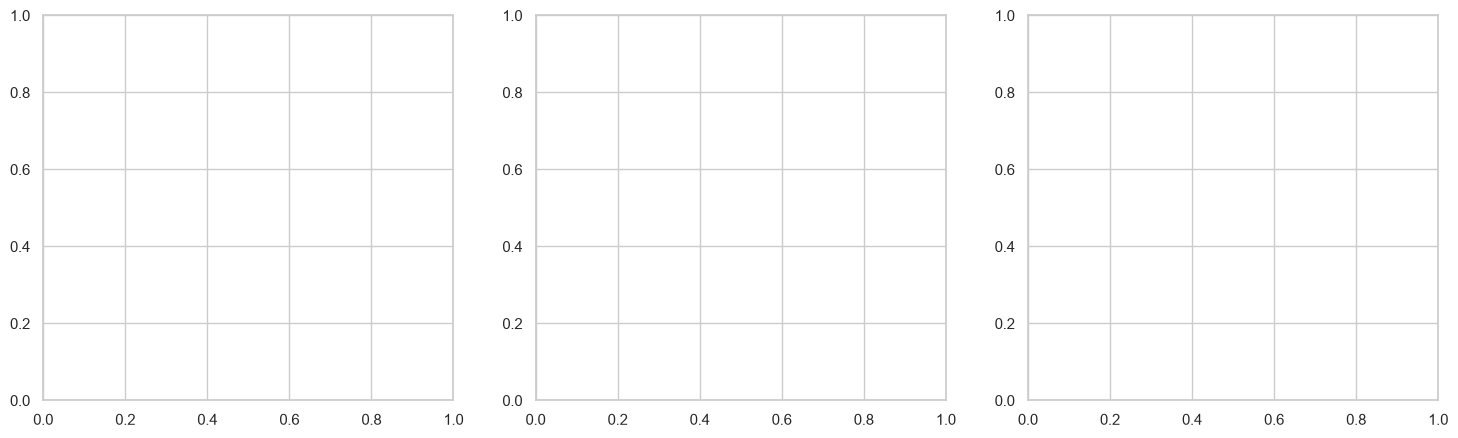

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
features  = [('areaM2', 'Área (m²)'), ('listedPrice', 'Precio (MXN)'), ('pricePerM2', 'Precio/m²')]

for ax, (col, label) in zip(axes, features):
    data   = [normal[normal['propertyType'] == pt][col].dropna().values
              for pt in normal['propertyType'].unique()]
    labels = normal['propertyType'].unique().tolist()
    ax.boxplot(data, labels=labels, showfliers=False)
    ax.set_title(f'{label} por tipo')
    ax.set_ylabel(label)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Distribución por tipo de propiedad (normales)', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Scatter plots — relaciones clave

Las anomalías deberían separarse visualmente de la nube de puntos normales.

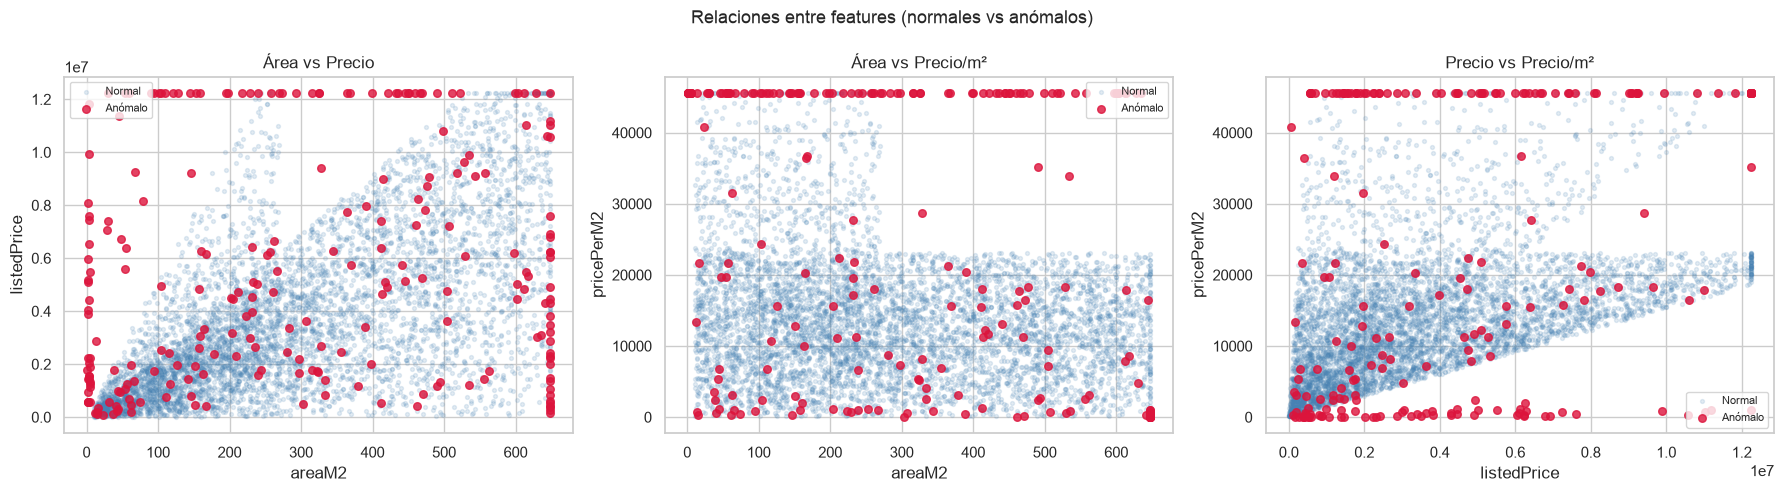

In [5]:
SCATTER_PAIRS = [
    ('areaM2',      'listedPrice',  'Área vs Precio'),
    ('areaM2',      'pricePerM2',   'Área vs Precio/m²'),
    ('listedPrice', 'pricePerM2',   'Precio vs Precio/m²'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (x, y, title) in zip(axes, SCATTER_PAIRS):
    # Limitar rango a percentil 99 de normales para legibilidad
    xlim = normal[x].quantile(0.99)
    ylim = normal[y].quantile(0.99)

    ax.scatter(normal[x].clip(0, xlim),   normal[y].clip(0, ylim),
               color='steelblue', alpha=0.15, s=8,  label='Normal')
    ax.scatter(anomalos[x].clip(0, xlim), anomalos[y].clip(0, ylim),
               color='crimson',   alpha=0.8,  s=30, label='Anómalo', zorder=5)

    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle('Relaciones entre features (normales vs anómalos)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Desglose por tipo de anomalía

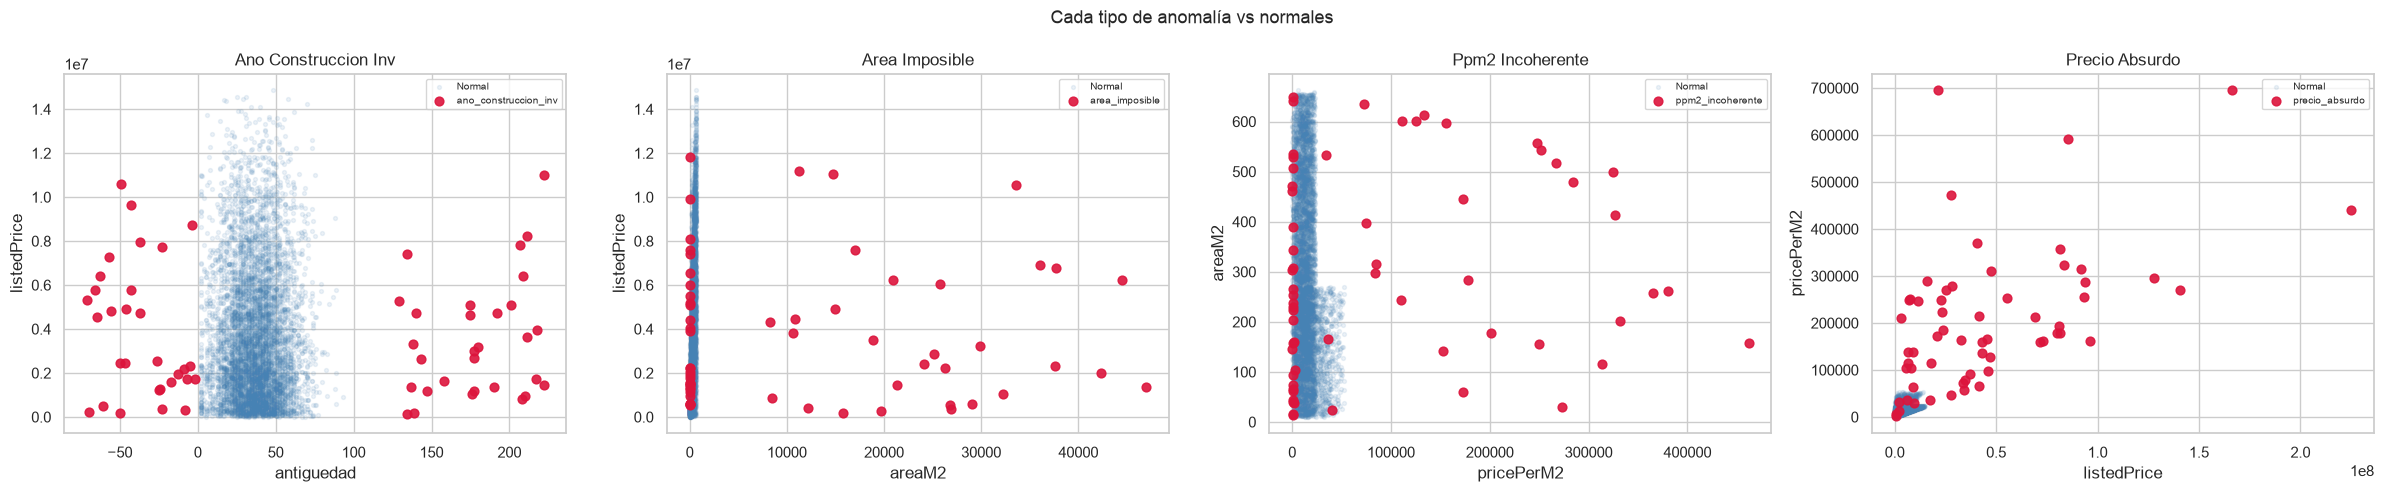

In [6]:
atype_cols = {
    'precio_absurdo'       : ('listedPrice', 'pricePerM2'),
    'area_imposible'       : ('areaM2',      'listedPrice'),
    'ppm2_incoherente'     : ('pricePerM2',  'areaM2'),
    'ano_construccion_inv' : ('antiguedad',  'listedPrice'),
}

atypes = anomalos['anomaly_type'].unique()
fig, axes = plt.subplots(1, len(atypes), figsize=(6 * len(atypes), 5))
if len(atypes) == 1:
    axes = [axes]

for ax, atype in zip(axes, atypes):
    x_col, y_col = atype_cols.get(atype, ('areaM2', 'listedPrice'))
    subset = anomalos[anomalos['anomaly_type'] == atype]

    xlim = normal[x_col].quantile(0.99)
    ylim = normal[y_col].quantile(0.99)

    ax.scatter(normal[x_col].clip(0, xlim * 1.5),  normal[y_col].clip(0, ylim * 1.5),
               color='steelblue', alpha=0.1, s=8,  label='Normal')
    ax.scatter(subset[x_col],  subset[y_col],
               color='crimson', alpha=0.9,  s=40, label=atype, zorder=5)

    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(atype.replace('_', ' ').title())
    ax.legend(fontsize=7)

plt.suptitle('Cada tipo de anomalía vs normales', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Correlaciones del dataset normal

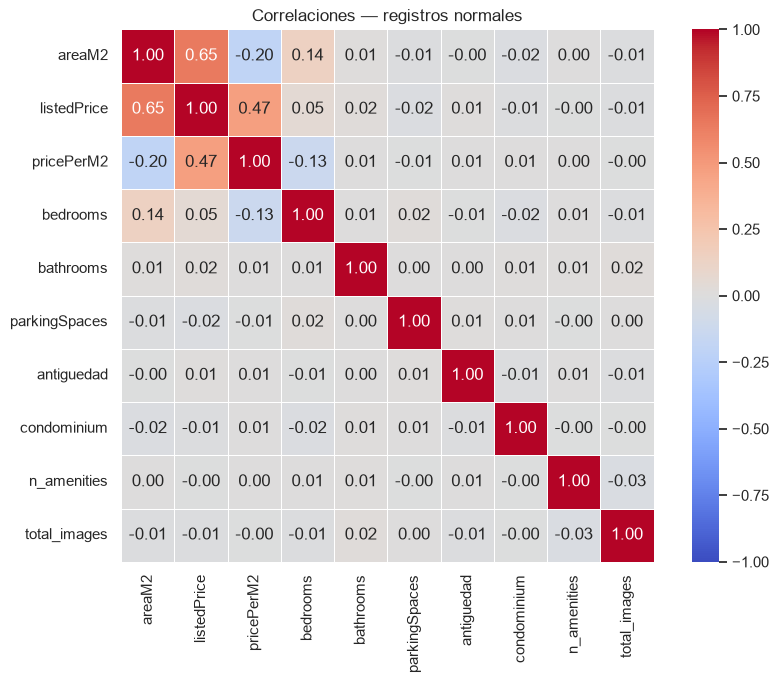

In [7]:
corr = normal[FEATURE_COLS].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, square=True)
plt.title('Correlaciones — registros normales')
plt.tight_layout()
plt.show()

## 7. Checklist de calidad del dataset

In [9]:
checks = {}

# 1. Sin nulos en features principales
checks['Sin nulos en features'] = normal[FEATURE_COLS].isnull().sum().sum() == 0

# 2. Precio positivo
checks['Precio listado > 0'] = (normal['listedPrice'] > 0).all()

# 3. Área razonable (10–8000 m²)
checks['Área en [10, 8000] m²'] = normal['areaM2'].between(10, 8000).all()

# 4. Año de construcción válido
checks['Año construcción en [1900, 2024]'] = normal['constructionYear'].between(1900, 2024).all()

# 5. pricePerM2 consistente con price/area (tolerancia ±20%)
derived_ppm2 = normal['listedPrice'] / normal['areaM2']
ratio = (normal['pricePerM2'] / derived_ppm2).clip(0.1, 10)
checks['pricePerM2 consistente con price/area'] = ratio.between(0.8, 1.25).mean() > 0.95

# 6. Proporción de anomalías entre 2% y 8%
anom_pct = df['is_anomaly'].mean()
checks[f'Proporción anomalías ({anom_pct:.1%}) entre 2% y 8%'] = 0.02 <= anom_pct <= 0.08

# 7. Al menos 4 tipos de propiedad
checks['≥4 tipos de propiedad'] = normal['propertyType'].nunique() >= 4

print('=== CHECKLIST DE CALIDAD ===')
all_pass = True
for check, result in checks.items():
    status = '✅' if result else '❌'
    print(f'  {status}  {check}')
    if not result:
        all_pass = False

print()
print('✅ Dataset listo para entrenamiento.' if all_pass else '❌ Revisar los checks fallidos antes de entrenar.')

=== CHECKLIST DE CALIDAD ===
  ✅  Sin nulos en features
  ✅  Precio listado > 0
  ✅  Área en [10, 8000] m²
  ✅  Año construcción en [1900, 2024]
  ✅  pricePerM2 consistente con price/area
  ✅  Proporción anomalías (3.8%) entre 2% y 8%
  ❌  ≥4 tipos de propiedad

❌ Revisar los checks fallidos antes de entrenar.
